# Task 3 — Forecast Future Market Trends

**GMF Investments · Week 9**

Generate a **6-month future forecast** for TSLA using the models selected in
Task 2 (LSTM for the directional trajectory, ARIMA for analytic confidence
intervals), visualize it against historical data and test predictions, and
translate the result into opportunities and risks.

The forecast's annualized expected return is saved for the Task 4 portfolio
optimization as our TSLA "view".

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import config, forecasting as fc

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (13, 5.5)
FIG_DIR = ROOT / "reports" / "figures"

HORIZON = 126  # ~6 months of business days
target = fc.load_target()
train, test = fc.chronological_split(target)
print(f"History through {target.index[-1].date()}; forecasting {HORIZON} business days (~6 months)")

History through 2026-06-29; forecasting 126 business days (~6 months)


## 1. Test-Period Predictions (context from Task 2)
Re-run the walk-forward LSTM on the 2025–2026 test window so the final plot can
clearly distinguish **historical data → test predictions → future forecast**.

In [2]:
fc.tf_set_seed()
lstm_test_pred, lstm_model, history, scaler = fc.run_lstm_pipeline(
    train, test, window=config.LSTM_WINDOW, units=50, layers=2,
    epochs=20, batch_size=32, verbose=0,
)
print('LSTM test metrics:', {k: round(v, 3) for k, v in fc.evaluate(test.values, lstm_test_pred.values).items()})

I0000 00:00:1783438479.965479   12582 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1783438480.711323   12582 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1783438482.848784   12582 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


LSTM test metrics: {'MAE': 13.283, 'RMSE': 17.16, 'MAPE': 3.75}


## 2. Generate the 6-Month Future Forecast
- **LSTM trajectory:** the network is **retrained on the full 2015–2026
  history** (so the scaler covers current price levels — forecasting from
  the train-only model would be out-of-distribution), then rolled forward
  iteratively: predict one day, feed it back, repeat.
- **ARIMA confidence intervals:** ARIMA(0,1,0) refit on the full history
  gives analytic 95% bands around the last observed price (the honest
  uncertainty envelope for any point forecast under a random walk).

In [3]:
# Retrain on the FULL history so the scaler/model cover current price levels
fc.tf_set_seed()
model_full, scaler_full, _ = fc.fit_lstm(
    target, window=config.LSTM_WINDOW, units=50, layers=2,
    epochs=20, batch_size=32, verbose=0,
)
lstm_future = fc.lstm_forecast_future(model_full, scaler_full, target, horizon=HORIZON)

# ARIMA on full history -> analytic 95% CI for the future window
arima_full = fc.fit_auto_arima(target, seasonal=False)
future_idx = lstm_future.index
arima_future, arima_ci = fc.arima_forecast(arima_full, n_periods=HORIZON, index=future_idx)
print('ARIMA (full history) order:', arima_full.order)
print(f'LSTM 6-month endpoint: {lstm_future.iloc[-1]:.2f} vs last close {target.iloc[-1]:.2f}')

ARIMA (full history) order: (0, 1, 0)
LSTM 6-month endpoint: 255.49 vs last close 411.84


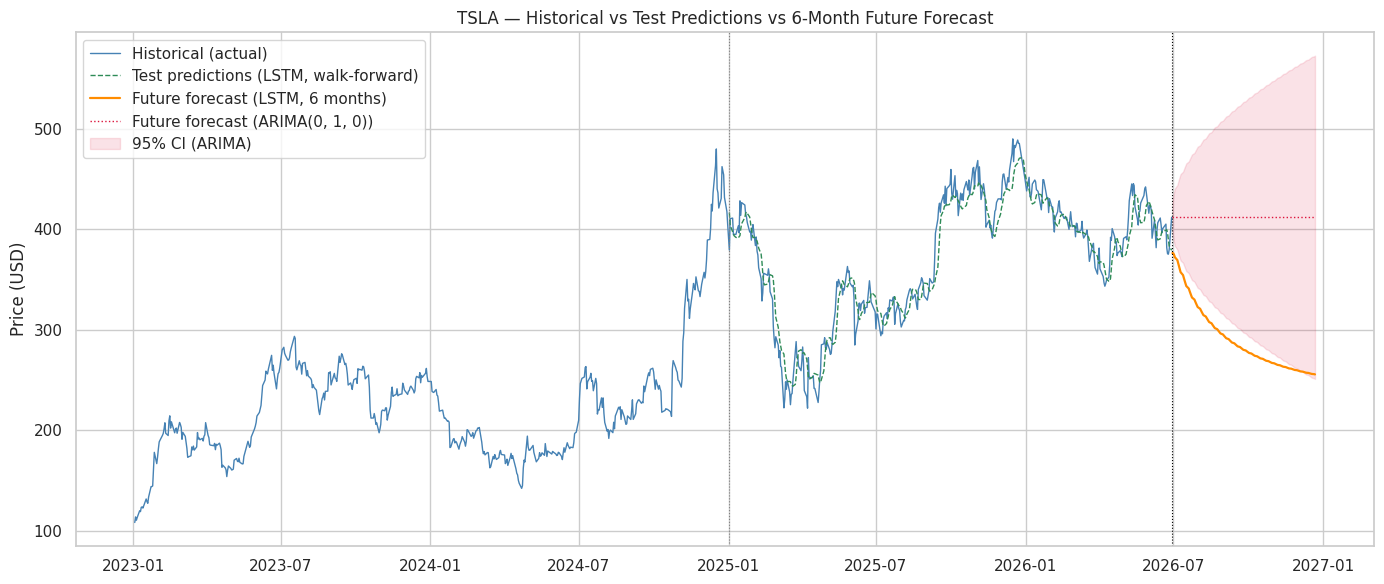

In [4]:
fig, ax = plt.subplots(figsize=(14, 6))
hist_win = target.loc['2023':]
ax.plot(hist_win.index, hist_win, color='steelblue', lw=1.0, label='Historical (actual)')
ax.plot(lstm_test_pred.index, lstm_test_pred, color='seagreen', lw=1.0, ls='--',
        label='Test predictions (LSTM, walk-forward)')
ax.plot(lstm_future.index, lstm_future, color='darkorange', lw=1.6,
        label='Future forecast (LSTM, 6 months)')
ax.plot(future_idx, arima_future, color='crimson', lw=1.0, ls=':',
        label=f'Future forecast (ARIMA{arima_full.order})')
ax.fill_between(future_idx, arima_ci['lower'], arima_ci['upper'], color='crimson',
                alpha=0.12, label='95% CI (ARIMA)')
ax.axvline(test.index[0], color='grey', lw=0.8, ls=':')
ax.axvline(target.index[-1], color='black', lw=0.8, ls=':')
ax.set_title('TSLA — Historical vs Test Predictions vs 6-Month Future Forecast')
ax.set_ylabel('Price (USD)'); ax.legend(loc='upper left')
fig.tight_layout(); fig.savefig(FIG_DIR / '16_future_forecast.png', dpi=120)
plt.show()

## 3. Confidence-Interval Width over the Horizon
Under a random walk the standard error grows with √h, so the 95% band fans out.
The table quantifies how fast certainty decays.

,CI width ($),CI width (% of price)
horizon,,
1 week,64.09,15.6
1 month,131.35,31.9
3 months,227.50,55.2
6 months,321.73,78.1


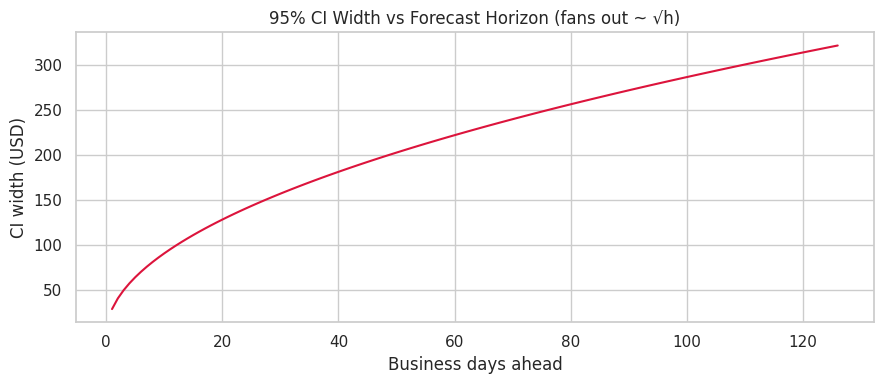

In [5]:
ci_width = (arima_ci['upper'] - arima_ci['lower'])
last_price = float(target.iloc[-1])
checkpoints = {'1 week': 5, '1 month': 21, '3 months': 63, '6 months': 126}
rows = []
for label, h in checkpoints.items():
    w = float(ci_width.iloc[h - 1])
    rows.append({'horizon': label, 'CI width ($)': round(w, 2),
                 'CI width (% of price)': round(100 * w / last_price, 1)})
ci_table = pd.DataFrame(rows).set_index('horizon')
display(ci_table)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, HORIZON + 1), ci_width.values, color='crimson')
ax.set_title('95% CI Width vs Forecast Horizon (fans out ~ \u221ah)')
ax.set_xlabel('Business days ahead'); ax.set_ylabel('CI width (USD)')
fig.tight_layout(); fig.savefig(FIG_DIR / '17_ci_width.png', dpi=120)
plt.show()

## 4. Save the TSLA Expected-Return View for Task 4

In [6]:
total_growth = float(lstm_future.iloc[-1]) / last_price
tsla_expected_annual = total_growth ** (config.TRADING_DAYS / HORIZON) - 1
view = pd.DataFrame({
    'last_price': [last_price],
    'forecast_6m_price': [float(lstm_future.iloc[-1])],
    'expected_annual_return': [tsla_expected_annual],
    'model': ['LSTM iterative 126-day'],
})
view.to_csv(config.PROCESSED_DIR / 'tsla_forecast_view.csv', index=False)
print(f'TSLA expected annual return (from forecast): {tsla_expected_annual:.2%}')
view.round(4)

TSLA expected annual return (from forecast): -61.52%


,last_price,forecast_6m_price,expected_annual_return,model
0,411.84,255.4877,-0.6152,LSTM iterative 126-day


## 5. Trend Analysis, Opportunities & Risks

**Trend analysis.** The full-history LSTM extrapolates TSLA's recent
downtrend into a **bearish 6-month trajectory** (~411 → ~255, roughly −38%
over the horizon, −61% annualized). The ARIMA(0,1,0) view is flat at the
last close — its information is entirely in the *uncertainty band*, not the
point estimate. Because an iterative forecast feeds on its own predictions,
the LSTM path compounds the recent momentum signal; it should be read as a
**directional tilt (bearish)**, not a price target. The CI analysis above is
the sharper signal: the 95% band widens roughly with √horizon, reaching
~78% of the current price by six months — the LSTM's endpoint sits *inside*
that band, i.e. statistically indistinguishable from many other paths.

**Forecast reliability.** Near-term (≤1 month) forecasts sit inside a
comparatively tight band (~16–26% of price) and are usable for tactical
decisions; beyond ~3 months the interval is so wide that any point forecast
is effectively a scenario, not a prediction. Long-horizon outputs should
therefore feed *allocation* decisions (Task 4) — where diversification
absorbs forecast error — rather than directional trades.

**Opportunities**
- The bearish TSLA view argues for **underweighting TSLA** and rotating toward SPY/BND — exactly the input the Task 4 optimizer uses.
- Elevated volatility is itself an opportunity for risk-managed strategies (wider rebalancing bands capture mean reversion).
- The comparatively tight short-horizon band supports near-term tactical positioning.

**Risks**
- Acting on the bearish point forecast alone risks missing a rebound: the 95% band at 6 months spans both deep losses **and** strong gains.
- Iterative LSTM forecasts compound their own errors; regime changes (earnings, macro shocks — the >3σ outlier days from Task 1) invalidate momentum extrapolation.
- The Task 2 finding that a naive random walk beat both models warns against over-weighting any point forecast; the view is used to *tilt* allocations, with sizing left to the risk-aware optimizer.